In [1]:
!pip install numpy
!pip install pandas
!pip install matplotlib
!pip install scikit-learn
!pip install graphviz

In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score

df = pd.read_csv("mobile_price.csv")

X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values


#先切train60% /temp40%
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.4,
    random_state=42,
    shuffle=True
)

#再把temp切成val20% /test20%
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42,
    shuffle=True
)

print("Train size:", len(X_train))
print("Val size:", len(X_val))
print("Test size:", len(X_test))


Train size: 1200
Val size: 400
Test size: 400


In [3]:
model = SVC(C=1.0)

model.fit(X_train, y_train)

def evaluate(name, X, y):
    y_pred = model.predict(X)

    acc = accuracy_score(y, y_pred)
    f1 = f1_score(y, y_pred, average='macro')

    print(f"{name}:")
    print(f"  Accuracy = {acc:.4f}")
    print(f"  F1-score = {f1:.4f}")
    print()

evaluate("Training", X_train, y_train)
evaluate("Validation", X_val, y_val)
evaluate("Testing", X_test, y_test)

Training:
  Accuracy = 0.9450
  F1-score = 0.9446

Validation:
  Accuracy = 0.9450
  F1-score = 0.9453

Testing:
  Accuracy = 0.9575
  F1-score = 0.9569



In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score

C_values = [0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000]

results = []

# 訓練與評估
for C in C_values:
    model = SVC(C=C)

    model.fit(X_train, y_train)

    # prediction
    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)
    y_test_pred = model.predict(X_test)

    # accuracy
    train_acc = accuracy_score(y_train, y_train_pred)
    val_acc = accuracy_score(y_val, y_val_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    # f1-score (multi-class 用 macro)
    train_f1 = f1_score(y_train, y_train_pred, average='macro')
    val_f1 = f1_score(y_val, y_val_pred, average='macro')
    test_f1 = f1_score(y_test, y_test_pred, average='macro')

    results.append({
        "C": C,
        "train_acc": train_acc,
        "val_acc": val_acc,
        "test_acc": test_acc,
        "train_f1": train_f1,
        "val_f1": val_f1,
        "test_f1": test_f1
    })

# 轉成表格
results_df = pd.DataFrame(results)

print(results_df.round(4))

           C  train_acc  val_acc  test_acc  train_f1  val_f1  test_f1
0      0.001     0.2550   0.2450    0.2400    0.1016  0.0984   0.0968
1      0.010     0.4908   0.4875    0.4425    0.3673  0.3466   0.3399
2      0.100     0.9050   0.9025    0.9000    0.9049  0.9025   0.8988
3      1.000     0.9450   0.9450    0.9575    0.9446  0.9453   0.9569
4     10.000     0.9658   0.9575    0.9650    0.9658  0.9577   0.9646
5    100.000     0.9792   0.9725    0.9775    0.9792  0.9725   0.9774
6   1000.000     0.9900   0.9700    0.9775    0.9900  0.9700   0.9773
7  10000.000     0.9975   0.9700    0.9650    0.9975  0.9700   0.9646


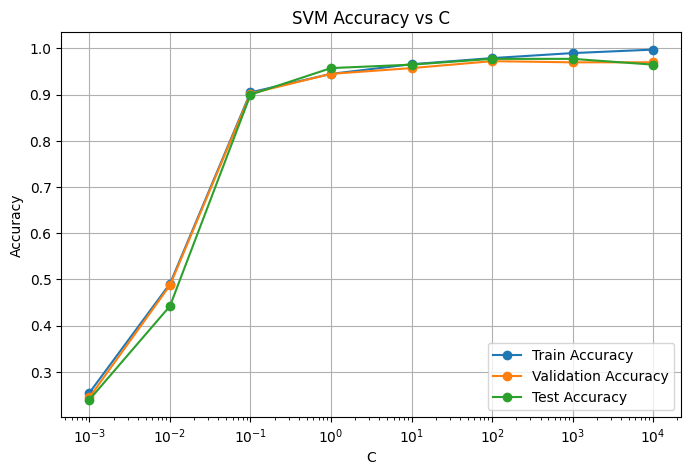

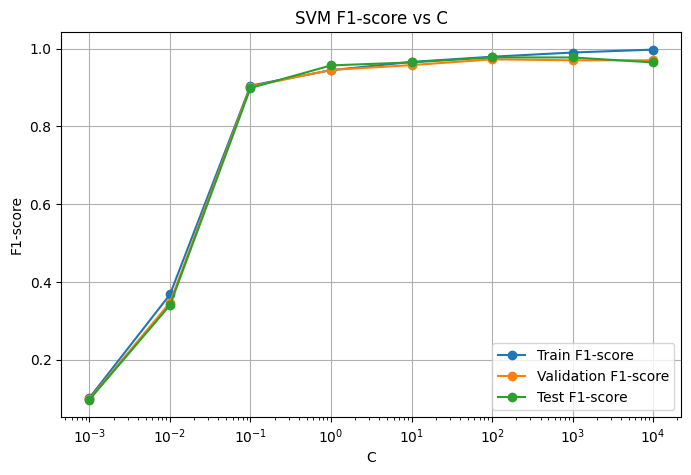

In [5]:
# =========================================================
# 5. Visualization
# =========================================================
plt.figure(figsize=(8, 5))
plt.plot(results_df["C"], results_df["train_acc"], marker='o', label='Train Accuracy')
plt.plot(results_df["C"], results_df["val_acc"], marker='o', label='Validation Accuracy')
plt.plot(results_df["C"], results_df["test_acc"], marker='o', label='Test Accuracy')
plt.xscale('log')
plt.xlabel("C")
plt.ylabel("Accuracy")
plt.title("SVM Accuracy vs C")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(results_df["C"], results_df["train_f1"], marker='o', label='Train F1-score')
plt.plot(results_df["C"], results_df["val_f1"], marker='o', label='Validation F1-score')
plt.plot(results_df["C"], results_df["test_f1"], marker='o', label='Test F1-score')
plt.xscale('log')
plt.xlabel("C")
plt.ylabel("F1-score")
plt.title("SVM F1-score vs C")
plt.legend()
plt.grid(True)
plt.show()